# SULO Pizza Tutorial — Spatial Containment and Movement

# Learning objectives

* Distinguish *parthood* (`hasPart`) from *spatial containment* (`spatiallyContains`)
* Understand why containment is not transitive across part-whole boundaries
* Model a pizza's movement through containers during the delivery process
* Define a `DeliveringThePizza` process and link it to the full process chain

# Containment vs. Parthood

In notebook 01 we established that a `Pizza` *has as a part* a `PizzaCrust`, which in turn *has as a part* a `Cornicione`. This **mereological** (part-whole) relation is transitive, compositional, and identity-defining: removing the crust destroys the pizza.

Spatial containment is different. An oven *contains* the pizza while baking; a delivery box *contains* the pizza during transport. But the pizza is not a **part** of the oven or the box:

| Property | `hasPart` | `spatiallyContains` |
|---|---|---|
| Transitivity | Yes — hasPart is transitive | Yes — a fridge contains a box that contains a pizza, so the fridge contains the pizza |
| Compositionality | Yes — parts constitute the whole | No — the pizza is not constitutive of the box |
| Identity-defining | Yes | No |
| Reversible | No — remove a part and the whole is changed | Yes — pizza can move in and out |

Notebook 01 already mentioned this distinction conceptually. Here we formalise it in OWL.

In [1]:
import sys, os
# Locate project root (the directory containing lib/) regardless of CWD
for _p in ['.', '..', '../..']:
    if os.path.isdir(os.path.join(_p, 'lib')):
        os.chdir(_p); sys.path.insert(0, os.getcwd()); break

from lib.helpers import *
onto_path.append(".")
sulo = get_ontology("dist/sulo.owl").load()
se = get_ontology("dist/sulo-ext.owl").load()
pizza = get_ontology("dist/pizza-05.owl").load()
pizza.imported_ontologies.append(sulo)
pizza.imported_ontologies.append(se)

print("Classes in pizza ontology:", len(list(pizza.classes())))

Classes in pizza ontology: 54


## Container Subclasses

We now define three container classes relevant to the pizza lifecycle:

| Class | Role |
|---|---|
| `PizzaOven` | Bakes the pizza; the pizza is contained in the oven during `BakingThePizza` |
| `PizzaDeliveryBox` | Transports the pizza after slicing |
| `CustomerTable` | The pizza's final destination |

Each is a `sulo:SpatialObject` that *spatially contains* some pizza.

In [2]:
with pizza:
    class SpatialRole(sulo.Role):
        """A spatial relation in which one spatial object is contained within another."""
        pass

    class ContainerRole(SpatialRole):
        """A spatial role whose primary function is to contain other spatial objects."""
        pass

    class PizzaOven(sulo.SpatialObject):
        """A heated enclosed chamber in which pizzas are baked."""
        pass

    class PizzaDeliveryBox(sulo.SpatialObject):
        """A box used to transport a pizza from the pizzeria to the customer."""
        pass

    class CustomerTable(sulo.SpatialObject):
        """The table surface at which the customer receives and eats the pizza."""
        pass

print("Container classes defined.")

Container classes defined.


## Demonstrating Containment Is Not Parthood

Here is the key ontological lesson: even though containment is transitive *within itself*, it does not propagate into `hasPart`. The `PizzaDeliveryBox` contains the pizza, and the pizza has a `PizzaCrust` as a part, but this does **not** mean the box has a crust as a part.

We demonstrate this with individuals.

In [3]:
with pizza:
    # Specific instances
    my_pizza  = pizza.TraditionalFourCheesePizza("pizza_for_delivery")
    my_box    = pizza.PizzaDeliveryBox("delivery_box_001")
    my_crust  = pizza.PizzaCrust("crust_of_my_pizza")
    my_fridge = sulo.SpatialObject("fridge_001")

    # Mereological relation: my_pizza hasPart my_crust
    my_pizza.hasDirectPart = [my_crust]

    # Containment relations
    my_box.contains    = [my_pizza]
    my_fridge.contains = [my_box]

    # Ensure all are different
    AllDifferent([my_pizza, my_box, my_crust, my_fridge])

result = safe_call_reasoner(pizza)
print("Consistent:", result["ok"])

# Transitivity of contains: fridge contains pizza (via box)
print("\nfridge contains (direct):", my_fridge.contains)
print("fridge INDIRECT_contains:", my_fridge.INDIRECT_contains)
print("\n")

# Transitivity of contains: box contains pizza 
print("box contains (direct):", my_box.contains)
print("box INDIRECT_contains:", my_box.INDIRECT_contains)

# hasPart does NOT propagate through spatiallyContains
print("\nmy_box hasPart (should be empty):", my_box.hasPart)
print("my_box INDIRECT_hasPart (should only have itself as a part):", my_box.INDIRECT_hasPart)

Consistent: True

fridge contains (direct): [pizza-05.delivery_box_001]
fridge INDIRECT_contains: [pizza-05.Cheese, pizza-05.delivery_box_001, pizza-05.PecorinoRomano, pizza-05.PizzaCrust, pizza-05.Parmesan, pizza-05.pizza_for_delivery, pizza-05.Mozzarella, pizza-05.Cornicione, pizza-05.Pizza & sulo.hasDirectPart.exactly(1, pizza-05.Mozzarella) & sulo.hasDirectPart.exactly(1, pizza-05.Gorgonzola) & sulo.hasDirectPart.exactly(1, pizza-05.Parmesan) & sulo.hasDirectPart.exactly(1, pizza-05.PecorinoRomano) & sulo.hasDirectPart.only(pizza-05.Mozzarella | pizza-05.Gorgonzola | pizza-05.Parmesan | pizza-05.PecorinoRomano), pizza-05.Gorgonzola]


box contains (direct): [pizza-05.pizza_for_delivery]
box INDIRECT_contains: [pizza-05.Cheese, pizza-05.PecorinoRomano, pizza-05.PizzaCrust, pizza-05.Parmesan, pizza-05.pizza_for_delivery, pizza-05.Mozzarella, pizza-05.Cornicione, pizza-05.Pizza & sulo.hasDirectPart.exactly(1, pizza-05.Mozzarella) & sulo.hasDirectPart.exactly(1, pizza-05.Gorgonzola) & 

## Modelling Pizza Movement in a Process

The delivery process involves the pizza *moving* from one container to another:
1. After slicing, the pizza is placed **into the delivery box** (pizza becomes spatially contained by box)
2. The box is transported to the customer
3. At delivery, the pizza is removed from the box and placed **on the customer table**

We model `DeliveringThePizza` as a process that connects these containment states.

In [4]:
with pizza:
    class DeliveringThePizza(se.TransformationProcess):
        """A process in which the sliced pizza is transported from the pizzeria to the customer.
        Input: a pizza contained in a delivery box.
        Output: the pizza placed on the customer's table (no longer in the box)."""
        is_a = [
            sulo.hasParticipant.some(pizza.PizzaSlice),
            sulo.hasParticipant.some(PizzaDeliveryBox),
            sulo.hasParticipant.some(CustomerTable),
        ]

# Extend the process chain from notebook 03
with pizza:
    pizza.SlicingThePizza.is_a.append(sulo.precedes.some(DeliveringThePizza))

print("DeliveringThePizza defined and chained.")
for a in pizza.SlicingThePizza.is_a:
    print(" SlicingThePizza is_a:", a)

DeliveringThePizza defined and chained.
 SlicingThePizza is_a: sulo-ext.DecompositionProcess
 SlicingThePizza is_a: sulo-ext.hasDirectParticipant.exactly(1, pizza-05.Pizza)
 SlicingThePizza is_a: sulo-ext.hasDirectParticipant.min(4, pizza-05.PizzaSlice)
 SlicingThePizza is_a: sulo.atTime.some(pizza-05.DeliveryTime)
 SlicingThePizza is_a: sulo.precedes.some(pizza-05.DeliveringThePizza)


## A Defined Class: `BoxedPizza`

A `BoxedPizza` is a `Pizza` that is spatially contained in a `PizzaDeliveryBox`. This is a defined class because we give necessary **and** sufficient conditions.

In [5]:
with pizza:
    class BoxedPizza(pizza.Pizza):
        """A pizza that is currently inside a delivery box."""
        equivalent_to = [pizza.Pizza & sulo.isIn.some(PizzaDeliveryBox)]

result = safe_call_reasoner(pizza)
print("Consistent:", result["ok"])

# Classify my_pizza — is it now a BoxedPizza?
inferred = [t for t in my_pizza.is_a if hasattr(t, 'name')]
print("my_pizza inferred types:", inferred)

Consistent: True
my_pizza inferred types: [pizza-05.TraditionalFourCheesePizza, pizza-05.BoxedPizza]


Saved pizza-06.owl


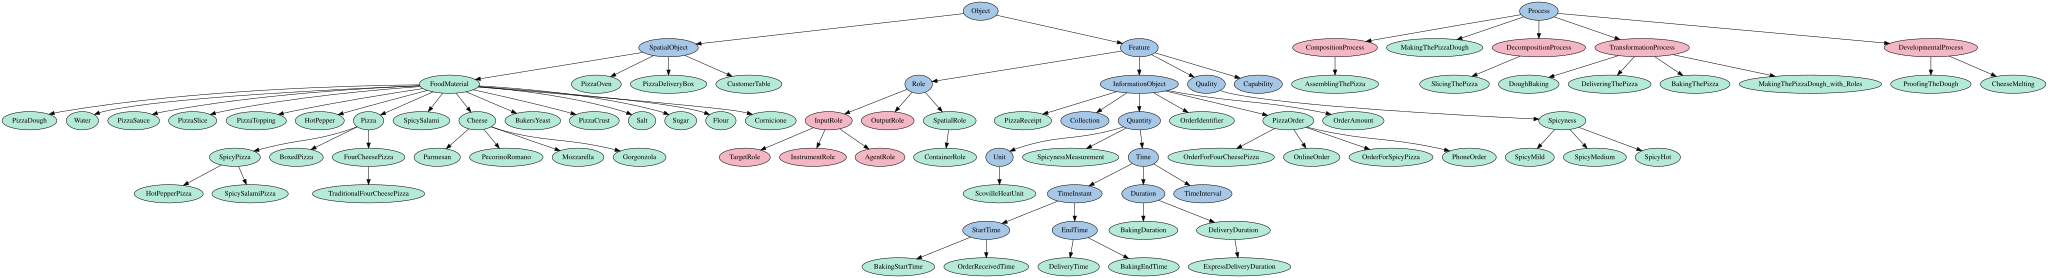

In [6]:
import os
os.makedirs("dist", exist_ok=True)
pizza.save(file="dist/pizza-06.owl", format="rdfxml")
print("Saved pizza-06.owl")
display(get_color_tree([sulo, se, pizza]))

---

## Exercises

### Exercise 1 — `RefrigeratedPizza`
Define a `Refrigerator` subclass of `ContainerObject`. Define `RefrigeratedPizza` as a `Pizza` that is `spatiallyContainedBy` some `Refrigerator`. Create a refrigerator individual and a pizza individual inside it, then verify the pizza is classified as `RefrigeratedPizza`.



In [7]:
# Exercise 1 — your code here


### Exercise 2 — Transitivity chain
Create a `Refrigerator` individual that `spatiallyContains` a `PizzaDeliveryBox`, which in turn `spatiallyContains` a pizza. Using `INDIRECT_spatiallyContains`, verify the refrigerator transitively contains the pizza. Then confirm that the refrigerator's `INDIRECT_hasPart` does **not** include the pizza's crust.



In [8]:
# Exercise 2 — your code here


### Exercise 3 — `StorageRoom`
A pizzeria may have a storage room that spatially contains all its ovens, delivery boxes, and ingredients. Define `PizzeriaStorageRoom` as a `ContainerObject`. Create individuals for an oven, a delivery box, and a `Flour` ingredient, all contained in the storage room. Define `WellStockedStorageRoom` as a `PizzeriaStorageRoom` that contains at least one `PizzaOven`, one `PizzaDeliveryBox`, and one `Flour`.



In [9]:
# Exercise 3 — your code here
